In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_DIR = "/content/drive/MyDrive/DGU-OpenSW-Team6/datasets/Sketch2AIA"
import os
os.listdir(DATASET_DIR)

['Sketch2aia_dataset']

In [9]:
import os
import json
from tqdm.auto import tqdm

DATASET_DIR = "/content/drive/MyDrive/DGU-OpenSW-Team6/datasets/Sketch2AIA/Sketch2aia_dataset"

CLASSES = ["Screen", "Label", "Button", "Switch", "Slider",
           "TextBox", "CheckBox", "ListPicker", "Image", "Map"]

def convert_json_to_yolo(json_path: str):
    data = json.load(open(json_path, "r"))

    img_w = data["imageWidth"]
    img_h = data["imageHeight"]

    lines = []

    for shape in data["shapes"]:
        label = shape["label"]
        if label not in CLASSES:
            continue

        cls_id = CLASSES.index(label)

        # points: [[x1, y1], [x2, y2]]
        (x1, y1), (x2, y2) = shape["points"]

        # 1) x1/x2, y1/y2 정렬
        x_min, x_max = sorted([x1, x2])
        y_min, y_max = sorted([y1, y2])

        # 2) 이미지 범위 안으로 강제 클립
        x_min = max(0.0, min(x_min, img_w - 1))
        x_max = max(0.0, min(x_max, img_w - 1))
        y_min = max(0.0, min(y_min, img_h - 1))
        y_max = max(0.0, min(y_max, img_h - 1))

        # 3) 잘못된 박스(너비/높이 0 이하)는 skip
        if x_max <= x_min or y_max <= y_min:
            continue

        # 4) center, width, height 계산 + 정규화
        cx = (x_min + x_max) / 2.0 / img_w
        cy = (y_min + y_max) / 2.0 / img_h
        w  = (x_max - x_min) / img_w
        h  = (y_max - y_min) / img_h

        # 5) 혹시 남은 오차 대비 안전하게 한 번 더 clip
        cx = max(0.0, min(cx, 1.0))
        cy = max(0.0, min(cy, 1.0))
        w  = max(0.0, min(w, 1.0))
        h  = max(0.0, min(h, 1.0))

        lines.append(f"{cls_id} {cx} {cy} {w} {h}")

    return lines


def process_split(split: str):
    split_dir = os.path.join(DATASET_DIR, split)
    print("processing:", split_dir)

    for fname in tqdm(os.listdir(split_dir)):
        if not fname.endswith(".json"):
            continue

        json_path = os.path.join(split_dir, fname)
        txt_path  = json_path.replace(".json", ".txt")

        yolo_lines = convert_json_to_yolo(json_path)

        with open(txt_path, "w") as f:
            f.write("\n".join(yolo_lines))


process_split("train")
process_split("val")

processing: /content/drive/MyDrive/DGU-OpenSW-Team6/datasets/Sketch2AIA/Sketch2aia_dataset/train


  0%|          | 0/711 [00:00<?, ?it/s]

processing: /content/drive/MyDrive/DGU-OpenSW-Team6/datasets/Sketch2AIA/Sketch2aia_dataset/val


  0%|          | 0/126 [00:00<?, ?it/s]

In [10]:
yaml_content = """
train: /content/drive/MyDrive/DGU-OpenSW-Team6/datasets/Sketch2AIA/Sketch2aia_dataset/train
val: /content/drive/MyDrive/DGU-OpenSW-Team6/datasets/Sketch2AIA/Sketch2aia_dataset/val

nc: 10
names: ["Screen", "Label", "Button", "Switch", "Slider",
        "TextBox", "CheckBox", "ListPicker", "Image", "Map"]
"""

with open("sketch2aia.yaml", "w") as f:
    f.write(yaml_content)

print("sketch2aia.yaml created.")

sketch2aia.yaml created.


In [11]:
!pip install ultralytics

In [12]:
sample_json = "/content/drive/MyDrive/DGU-OpenSW-Team6/datasets/Sketch2AIA/Sketch2aia_dataset/train/300.json"

with open(sample_json) as f:
    data = json.load(f)

print("imageWidth, imageHeight:", data["imageWidth"], data["imageHeight"])
print("first shape:", data["shapes"][0])

txt_path = sample_json.replace(".json", ".txt")
print(open(txt_path).read())

imageWidth, imageHeight: 1019 1650
first shape: {'label': 'Button', 'points': [[4.074074074074019, 0.9382716049382713], [190.49382716049377, 199.7037037037037]], 'group_id': None, 'shape_type': 'rectangle', 'flags': {}}
2 0.09547002023285957 0.06080059857837636 0.1829438204969772 0.12046389824167601
1 0.5098196004313112 0.21007108118219228 0.7523716061498201 0.06434717545828658
1 0.19421122136202273 0.3252974186307519 0.23988659906226137 0.0344182566404789
1 0.3020390360920291 0.4465095398428731 0.4143495801984515 0.029928918817807754
1 0.3117314239329286 0.566225215114104 0.4046571923575521 0.03591470258136924
1 0.3450490071360205 0.7038982416760193 0.40344564387743986 0.04040404040404045
1 0.3426259101757957 0.81351290684624 0.3549837046729425 0.03965581743359521
1 0.29234664825112977 0.9358473625140291 0.34165667139170575 0.03441825664047897
0 0.49891566411029936 0.5000074822297044 0.9922582052120815 0.9958847736625513


In [13]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")  # small 모델

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [14]:
model.train(
    data="sketch2aia.yaml",
    epochs=100,      # 100~150 추천
    imgsz=640,
    batch=8,
    workers=2,
    device=0        # GPU 런타임일 때
)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=sketch2aia.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d7ec9ba2e10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [17]:
!mkdir -p "/content/drive/MyDrive/DGU-OpenSW-Team6/models"

!cp /content/runs/detect/train/weights/best.pt \
    "/content/drive/MyDrive/DGU-OpenSW-Team6/models/ui_detector_sketch2aia.pt"


image 1/1 /content/drive/MyDrive/DGU-OpenSW-Team6/datasets/Sketch2AIA/Sketch2aia_dataset/val/107.jpg: 640x384 1 Screen, 2 Labels, 3 Buttons, 2 TextBoxs, 1 Image, 10.7ms
Speed: 1.8ms preprocess, 10.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 384)


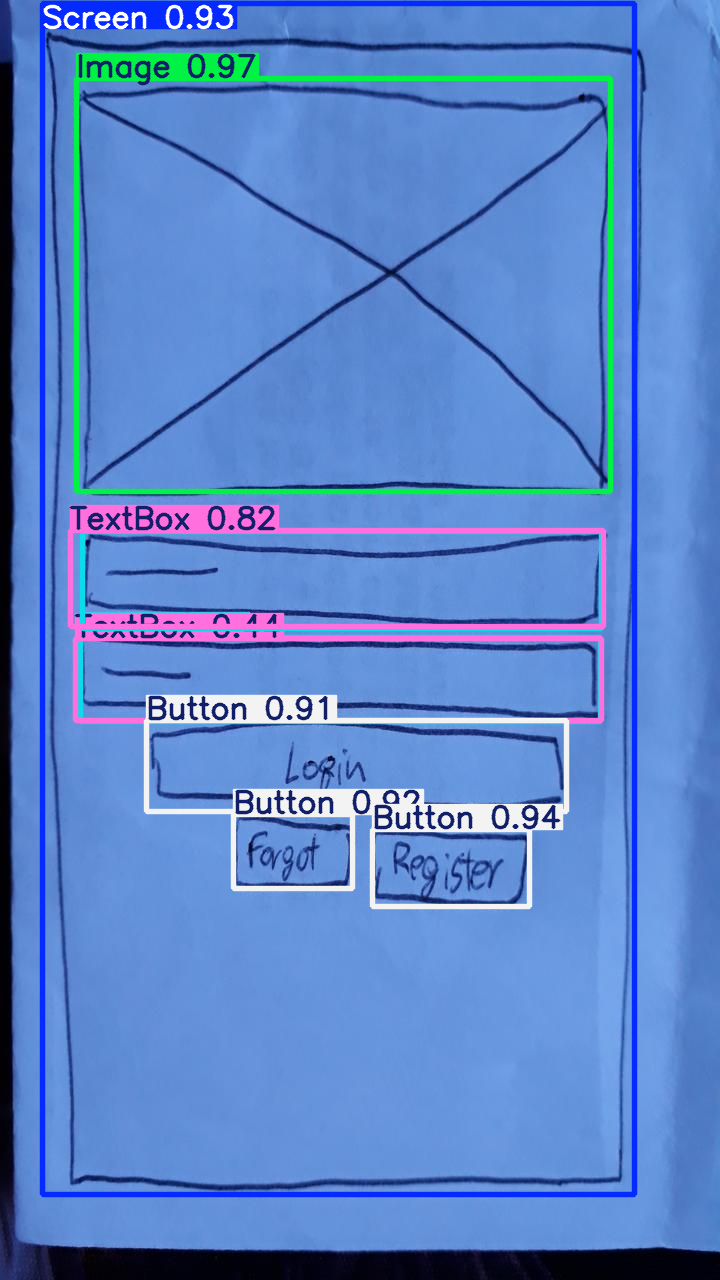

'pred_107.jpg'

In [27]:
import os

best_model = model  # 방금 학습한 model 객체 (또는 YOLO("runs/detect/train/weights/best.pt"))

test_img = "/content/drive/MyDrive/DGU-OpenSW-Team6/datasets/Sketch2AIA/Sketch2aia_dataset/val/107.jpg"

results = best_model(test_img, conf=0.25)
results[0].show()               # Colab 출력창에 bbox 띄우기
# 또는
results[0].save(filename="pred_107.jpg")